# Parte 7 · Biodiversity Long-Tail Challenge

**Lo que pide el enunciado (§11) y dónde está:**

| Pide | Dónde |
|---|---|
| Construir por código, con semilla, un escenario con especies frecuentes, intermedias y minoritarias | `preparar_datos.construir_long_tail` · §1 |
| Documentar criterio, clases por grupo, imágenes por grupo, distribución final | §1 |
| Balanceado vs. long-tail | L1 (balanceado del mismo tamaño) y T3 (500k) vs. L2 |
| Rendimiento separado por grupo | §3 |
| Al menos una estrategia de mitigación; LT sin corrección vs. con corrección | L3 CE ponderada, L4 logit adjustment, L5 weighted sampling |
| (§12) Métricas por grupo; precisión y recall por grupo de frecuencia | §3 |
| (§13) ¿Las minoritarias fallan distinto? ¿La mitigación mejora su recall? | §4 |

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

import datos
from sklearn.metrics import f1_score
lt = datos.long_tail()
grupo_de, n_por_clase = lt["grupo"], lt["n_por_clase"]
NOMBRES = [str(x) for x in lt["nombres_grupo"]]

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Construcción del escenario

**Criterio:** se baraja el orden de las 10 000 especies (semilla 42) y la especie de rango $r$ conserva
$n(r) = \lfloor 50 \cdot (1/50)^{r/(C-1)} \rfloor$ imágenes: un perfil exponencial de 50 a 1 (factor de
desbalance 50), como en CIFAR-LT e ImageNet-LT. Qué imágenes concretas se conservan también se sortea.
Barajar evita que el desbalance se alinee con la taxonomía. **Grupos:** frecuentes $n \ge 20$,
intermedias $5 \le n < 20$, minoritarias $n < 5$. La validación sigue siendo la oficial (10 por especie).

**Control L1:** balanceado con el **mismo número total de imágenes** (12 por especie). Sin él, la
comparación con T3 (500k imágenes) mezclaría el efecto del desbalance con el de tener 4 veces menos datos.

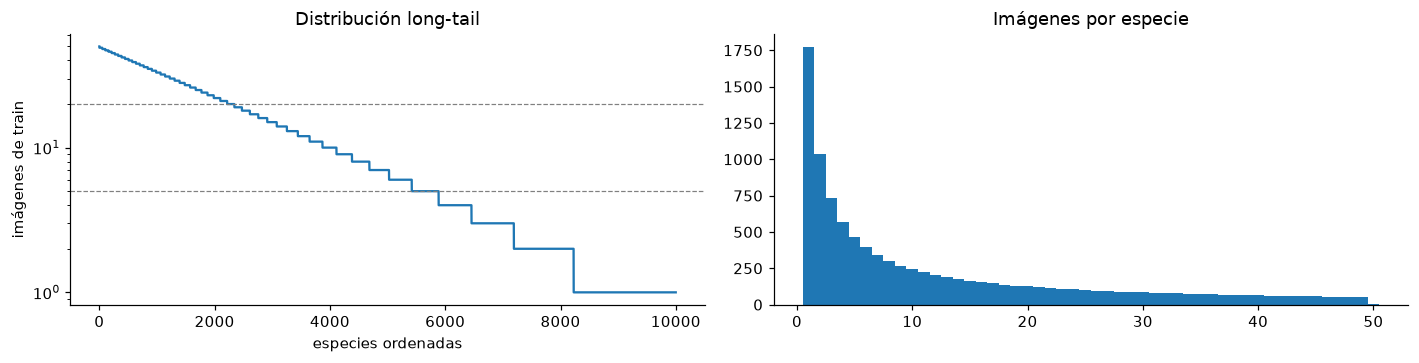

total long-tail: 120474 imágenes · control balanceado: 120000


,clases,imágenes,img/especie,% clases,% imágenes
frecuentes,2343,75550,20–50,23%,63%
intermedias,3543,36593,5–19,35%,30%
minoritarias,4114,8331,1–4,41%,7%


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(np.sort(n_por_clase)[::-1]); ax[0].set_yscale("log")
for u in (20, 5): ax[0].axhline(u, ls="--", c="gray", lw=.8)
ax[0].set_xlabel("especies ordenadas"); ax[0].set_ylabel("imágenes de train"); ax[0].set_title("Distribución long-tail")
ax[1].hist(n_por_clase, bins=np.arange(.5, 51.5)); ax[1].set_title("Imágenes por especie")
plt.tight_layout(); plt.show()
g = pd.DataFrame({"clases": [(grupo_de == k).sum() for k in range(3)],
                  "imágenes": [n_por_clase[grupo_de == k].sum() for k in range(3)],
                  "img/especie": [f"{n_por_clase[grupo_de == k].min()}–{n_por_clase[grupo_de == k].max()}" for k in range(3)]},
                 index=NOMBRES)
g["% clases"] = (g.clases / g.clases.sum()).map("{:.0%}".format)
g["% imágenes"] = (g.imágenes / g.imágenes.sum()).map("{:.0%}".format)
print(f"total long-tail: {len(lt['idx_lt'])} imágenes · control balanceado: {len(lt['idx_bal'])}")
g

## 2. Definición de los experimentos (receta de T3: ResNet-50 ImageNet, full fine-tuning)

In [3]:
definiciones([("L1", "T3"), ("L2", "L1"), ("L3", "L2"), ("L4", "L2"), ("L5", "L2")])

,referencia,descripción,estado,cambios
ID,,,,
L1,T3,"balanceado, mismo nº de imágenes que el long-t...",en curso (época 1),datos: completo → lt_balanceado
L2,L1,long-tail sin corrección,terminado,datos: lt_balanceado → longtail
L3,L2,long-tail + Weighted Cross-Entropy (1/n),terminado,perdida: ce → ce_ponderada
L4,L2,long-tail + Logit Adjustment (tau=1),terminado,perdida: ce → logit_ajustado
L5,L2,long-tail + Weighted Sampling,terminado,muestreo: uniforme → ponderado


| Mitigación | Idea | Implementación |
|---|---|---|
| **Weighted CE** (L3) | cada imagen pesa ∝ 1/n de su clase | `F.cross_entropy(weight=w)` |
| **Logit adjustment** (L4, Menon et al. 2021) | al entrenar se suma $\log \pi_y$ (prior de la clase) a los logits, así el modelo aprende $p(y\mid x)/p(y)$; en test se omite y la predicción queda "balanceada" | `crear_perdida` |
| **Weighted sampling** (L5) | cada imagen se muestrea con probabilidad ∝ 1/n: los lotes quedan balanceados en esperanza | `WeightedRandomSampler` |

## 3. Resultados globales y por grupo de frecuencia

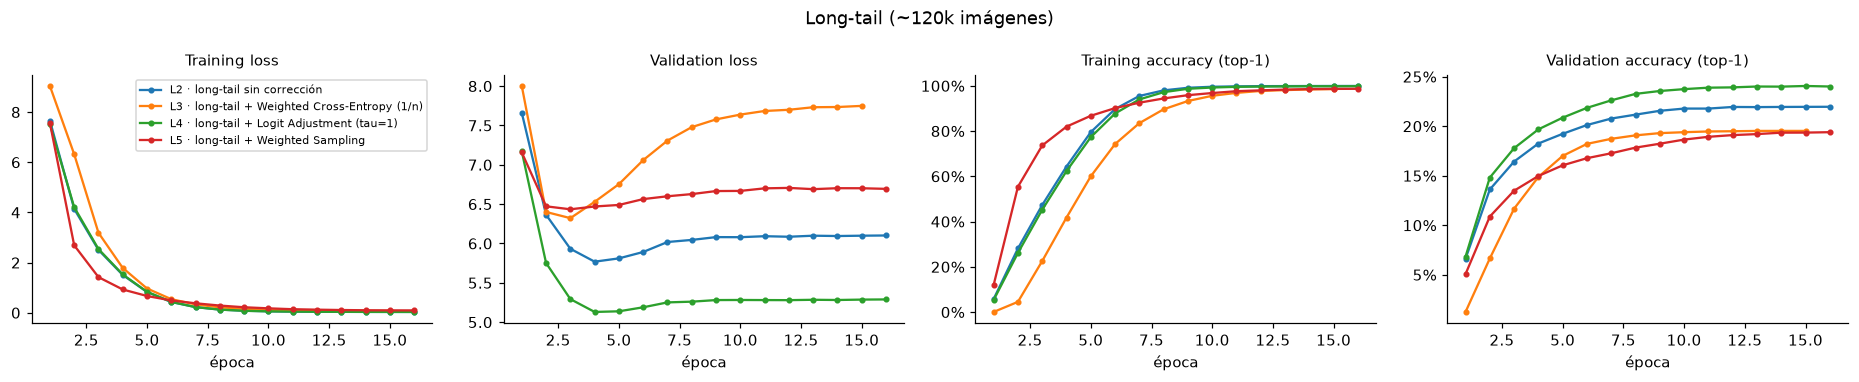

,descripción,top1,top5,f1_macro,f1_weighted,train_top1,brecha_top1,brecha_loss,mejor_ep,épocas,img_s,min_total,gpu
ID,,,,,,,,,,,,,
T3,C: Full Fine-Tuning,50.4%,72.1%,50.1%,50.1%,99.6%,49.2%,2.69,15,16,1444,115,A100 MIG 2g.10gb
L2,long-tail sin corrección,21.9%,38.9%,17.5%,17.5%,99.9%,78.0%,6.07,16,16,2973,11,RTX A6000
L3,long-tail + Weighted Cross-Entropy (1/n),19.5%,33.5%,15.5%,15.5%,98.4%,79.0%,7.66,14,15,2973,10,RTX A6000
L4,long-tail + Logit Adjustment (tau=1),24.0%,42.2%,21.4%,21.4%,99.8%,75.8%,5.25,15,16,2969,11,RTX A6000
L5,long-tail + Weighted Sampling,19.3%,34.3%,15.5%,15.5%,98.7%,79.3%,6.60,16,16,2496,13,A100 MIG 3g.20gb


In [4]:
curvas(R, ["L1", "L2", "L3", "L4", "L5"], "Long-tail (~120k imágenes)")
tabla(R, ["T3", "L1", "L2", "L3", "L4", "L5"]).drop(columns=["params_M", "entrenables_M", "GFLOPs"]).style.format(FMT)

In [5]:
def por_grupo(id_):
    p = np.load(R[id_]["dir"] / "preds.npz")
    y, pred = p["y"], p["top5"][:, 0].astype(int)
    ok5 = (p["top5"] == y[:, None]).any(1)
    gy, gp = grupo_de[y], grupo_de[pred]
    filas = {}
    for k, nom in enumerate(NOMBRES):
        m = gy == k
        filas[nom] = dict(recall_top1=(pred[m] == y[m]).mean(), top5=ok5[m].mean(),
                          precision=(pred[gp == k] == y[gp == k]).mean() if (gp == k).any() else np.nan,
                          f1_macro=f1_score(y, pred, labels=np.where(grupo_de == k)[0], average="macro", zero_division=0),
                          pct_predicciones=(gp == k).mean(), pct_clases=m.mean())
    return pd.DataFrame(filas).T

ids = [i for i in ["T3", "L1", "L2", "L3", "L4", "L5"] if i in R]
G = pd.concat({i: por_grupo(i) for i in ids}, names=["exp", "grupo"]) if ids else pd.DataFrame()
G.style.format("{:.1%}") if len(G) else None

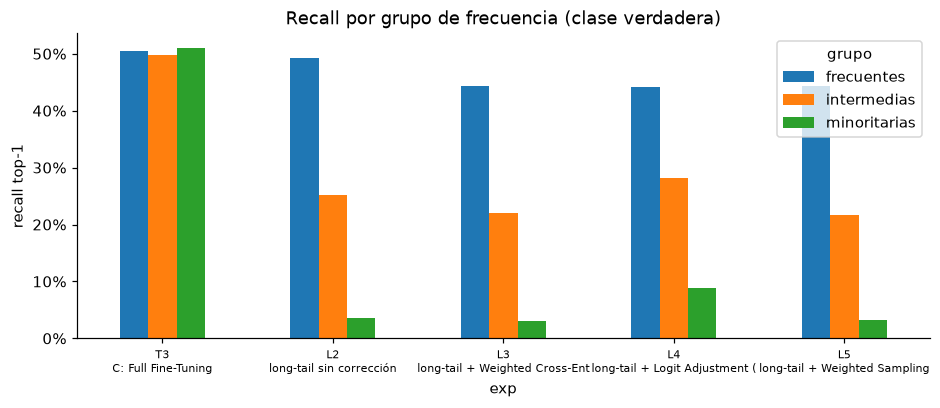

In [6]:
if len(G):
    piv = G["recall_top1"].unstack().reindex(columns=NOMBRES)
    ax = piv.plot.bar(figsize=(10, 3.6), rot=0)
    ax.set_ylabel("recall top-1"); ax.set_title("Recall por grupo de frecuencia (clase verdadera)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xticklabels([f"{i}\n{POR_ID[i].descripcion[:30]}" for i in piv.index], fontsize=7); plt.show()

**Cómo leer la tabla:** *recall* es el acierto sobre las imágenes cuya especie verdadera es del grupo.
*precision* es el acierto de las predicciones que caen en especies del grupo. *pct_predicciones* frente a
*pct_clases*: si el modelo predice un grupo más a menudo de lo que ese grupo aparece (validación
balanceada), está sesgado hacia él.

## 4. ¿Las minoritarias fallan de otra manera?
Para los errores sobre especies minoritarias: ¿a qué grupo pertenece la especie que el modelo predijo?

In [7]:
filas = {}
for i in [x for x in ["L1", "L2", "L3", "L4", "L5"] if x in R]:
    q = np.load(R[i]["dir"] / "preds.npz"); yy, pp = q["y"], q["top5"][:, 0].astype(int)
    m = (grupo_de[yy] == 2) & (pp != yy)
    filas[i] = pd.Series(grupo_de[pp[m]]).map(dict(enumerate(NOMBRES))).value_counts(normalize=True)
pd.DataFrame(filas).T.reindex(columns=NOMBRES).fillna(0).style.format("{:.1%}") if filas else None

,frecuentes,intermedias,minoritarias
L2,65.2%,31.4%,3.4%
L3,67.5%,29.4%,3.1%
L4,38.8%,39.2%,22.0%
L5,68.1%,28.4%,3.5%


## 5. Lectura

Recall top-1 por grupo de la especie verdadera y fracción de las predicciones que caen en cada grupo
(en una validación balanceada, lo "justo" sería 23 % / 35 % / 41 %):

| | Top-1 | Recall frecuentes | Recall intermedias | Recall minoritarias | % predicciones → frec. / inter. / minor. |
|---|---|---|---|---|---|
| T3 · 500k balanceado | 50,4 % | 50,5 % | 49,8 % | 51,0 % | 23 / 35 / 41 |
| L1 · 120k balanceado | ⏳ | ⏳ | ⏳ | ⏳ | ⏳ |
| **L2 · long-tail** | 21,9 % | 49,3 % | 25,1 % | **3,7 %** | **64** / 33 / **4** |
| L3 · + CE ponderada | 19,5 % | 44,3 % | 22,1 % | 3,1 % | 65 / 31 / 4 |
| **L4 · + logit adjustment** | **24,0 %** | 44,2 % | **28,1 %** | **8,9 %** | 40 / 40 / 20 |
| L5 · + weighted sampling | 19,3 % | 44,3 % | 21,6 % | 3,2 % | 66 / 30 / 4 |

* **El desbalance destroye las especies minoritarias.** Sin corrección (L2), las frecuentes conservan casi
  el mismo recall que con 500k imágenes balanceadas (49 % frente a 50 %), pero las minoritarias caen del
  51 % al **3,7 %**. El modelo predice una especie frecuente el 64 % de las veces aunque solo el 23 % de
  las imágenes lo son: aprendió el *prior* de entrenamiento. El 65 % de los errores sobre especies
  minoritarias se van a una especie frecuente.
* **Logit adjustment es la única mitigación que funciona:** sube el recall de las minoritarias de 3,7 % a
  **8,9 %** (2,4 veces) y el de las intermedias de 25 % a 28 %, a cambio de 5 pp en las frecuentes. El
  top-1 global mejora de 21,9 % a 24,0 %. Corrige casi exactamente el sesgo: las predicciones hacia
  especies frecuentes bajan del 64 % al 40 %.
* **CE ponderada y weighted sampling no sirven aquí, e incluso empeoran:** ambas dejan intacto el sesgo
  (65–66 % de predicciones frecuentes) y bajan el top-1. La explicación está en el train top-1: **98–99 %
  en todos los modelos long-tail.** Una ResNet-50 memoriza las 120k imágenes de entrenamiento. Cuando el
  modelo clasifica bien *todas* las imágenes de entrenamiento, dar más peso a unas (CE ponderada) o
  repetirlas (sampling) no cambia la solución a la que converge: solo cambia el camino. Es el resultado de
  Byrd & Lipton (2019) sobre la importancia de los pesos en redes sobreparametrizadas. Además, repetir 1–4
  imágenes decenas de veces por época lleva a sobreajustar antes (la val loss es mínima en la época 3).
  *Logit adjustment* no depende de eso: cambia el **margen** que se exige a cada clase, así que su efecto
  persiste aunque el train llegue al 100 %.
* **H3 se acepta:** logit adjustment recupera bastante más recall minoritario que la CE ponderada (8,9 %
  frente a 3,1 %). La segunda mitad ("pierde menos en las frecuentes") no se cumple: ambas pierden lo
  mismo (44 % frente a 49 %).
* **Pendiente (L1):** el control balanceado del mismo tamaño dirá cuánto de la caída de L2 se debe a la
  *forma* de la distribución y cuánto a tener 4 veces menos imágenes que T3.